In [1]:
#!/usr/bin/env python3
"""NMT-4K Comment mapping audit (fills your paper placeholder).

Reports:
  • number of unique raw `Comment` strings
  • fraction mapped to the 10-label vocabulary
    - shown for UNIQUE raw strings and for EVENT ROWS
  • list of unmapped raw labels (with counts)
  • writes full unmapped list to CSV for inspection

This script is built to use your existing `ab_label_dict_detail` dictionary.
"""

from __future__ import annotations

from pathlib import Path
import re
from collections import Counter

import pandas as pd
from tqdm import tqdm


# =========================
# PATHS (edit if needed)
# =========================
ROOT = Path("/media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split")
CSV_DIR = ROOT / "csv_fixed_channels_fczpz_updated"  # your annotation CSV folder

OUT = Path("./nmt4k_validation_out")
OUT.mkdir(parents=True, exist_ok=True)

# =========================
# CSV COLUMN
# =========================
COL_LABEL = "Comment"


# =========================
# LABEL MERGING DICTIONARY (yours)
# =========================
ab_label_dict_detail = [
    ['Normal',
     'Beta Wave','Beta waves', 'beta waves', 'Beta Wave', 'beta activity',
     'Alpha Coma', 'alpha coma'],

    ['Sharp Wave',
     'sharp waves', 'sharp wave', 'generalized sharp waves', 'generalized sharp waves discharge', 'Sharp Wave',
     'sharp and wave', 'sharp wave discharges', 'sharp wave pre del both',
     'Triphasic Wave', 'triphasic waves', 'periodic & semiperiodic & triphasic wave',
     'periodic & semiperiodic & triphasic wave  & complexes',
     'periodic & semiperiodic & triphasic wave & sharp & slow wave & complexes',
     'semi periodic triphasic', 'semi periodic triphasic wave', 'semiperiodic triphasic wave complexes',
     'triphaic waves', 'triphasic waves ( sharp waves)', 'triphasic waves (sharp waves)',
     'semiperiodic triphasic wavecomplexes', 'semiperiodic  triphasic wave',"triphasic waves'",
     'Burst Suppression', 'burst suppression', 'burst suppression pattern',
     'Sharp and slow Wave', 'focal sharp and slow wave', 'sharp and delta waves', 'sharp & delta wave',
     'sharp & slow wave activity', 'sharp and delta slow wave', 'sharp and slow wave activity',
     'sharp and slow wave discharges', 'slow and sharp wave', 'sharp & delta slow waves',
     'sharp and deta wave', 'sharp ans slow wave discharges', 'sharp and delta slow waves',
     'sharp and delta waves', 'sharp and delta wave', 'sharp and slow waves', 'sharp and slow wave'
    ],

    ['Delta Slow Wave',
     'delta slow wave', 'delta waves', 'delta slow waves', 'slowing wave',
     'generalized paroxymal delta slow waves', 'generalized paroxysmal delta slow waves',
     'generalized parosysmal delta slow waves', 'generalized delta slow waves', 'slow waves',
     'paroxysmal delta slow waves', 'paroxysmal generalized delta slow waves',
     'Delta', 'delta wave', 'changegeneralized delta slow waves', 'dela slow waves',
     'delta slow waves with muscle artifacts', 'delta slowing', 'frontal delta slowing',
     'frontal slow wave', 'frontal slow wave activity', 'generalized delta slow waves discharge',
     'generalized delta slowing', 'generalized slowing', 'generalized slowing in delta range',
     'mild  slowing', 'mild generalized slowing', 'slow wave', 'slow wave activity', 'slow wave discharges',
     'delta slow waves\\', 'delta wavest', 'delta low waves', 'delta slo waves', 'delta sloww aves',
     'delta sloww waves', 'delta slowwaves', 'generaliaed slowing', 'generalize slowing',
     'generalized  slowing', 'generalizied slowing', 'generalizwd delta slowing',
     'generilized slowing', 'generlized slowing', 'generralized slowing',
     'mild generilized slowing', 'mild generlized slowing',
     'delta prev','Generalized slowing mixed with Artifacts'
    ],

    ['Spike and Wave',
     '2 hertz slow spike and wave discharge', 'spike wave', 'spikes',
     'generalized paroxysmal spike and wave discharge', 'generalized paroxymal spike and wave discharge',
     'fragmented spike and wave discharge', 'generalized paroxysmal 3 hertz spike and wave discharge',
     'generalized spike and wave discharge', 'generalized spike and wave discharges',
     'spike and wave', 'spike and wave discharge', 'spike and waves', 'generalized spike and wave',
     'spike and wave ', ' spike and wave discharge', 'spike', 'spiek and wave',
     'Spike and Wave Discharge', '3hz spike and wave', '3hz spike and wave discharges',
     'brust of spike and wave', 'spike & wave discharges', 'spike and wave activity',
     'spike and wave discharges', 'spike snd wave', 'slow spike and wave',
     'spike and wave dischages', 'Rolandic Spikes', 'rolandic spike', 'rolandic spikes'
    ],

    ['Polyspike',
     'generalized plolyspikes discharge', 'generalized polyspike pattern',
     'polyspike and wave discharges', 'polyspike wave discharges', 'polyspikes & wave',
     'polypspikes and wave', 'generalized polyspikes discharge',
     'generalized polyspike discharge', 'polyspikes discharge', 'polyspikes and wave',
     'polyspikes', 'polyspike and wave'
    ],

    ['Spike Wave and Polyspike Wave',
     'generalized spike & polyspike pattern', 'generalized spike & polyspike wave',
     'spike & poilyspike wave', 'spike & polyspike', 'spike & polyspike and wave',
     'spike & polyspike wave', 'spike &polyspike and wave discharges',
     'spike / polyspike and wave discharges', 'spike/polyspike and wave discharges'
    ],

    ['Theta Wave',
     'theta waves', 'Theta Slow Wave', 'generalized slowing in theta range',
     'mild generilized slowing in theta range', 'theta slow waves', 'theta wavs'
    ],

    ['Delta and Theta Wave',
     'delta and theta waves', 'delta-theta slowing', 'frontal dela to theta slowing',
     'generalized slowing in delta to theta range', 'generalized slowing in delta-thta range'
    ],

    ['Spike And Delta Slow Waves',
     'spike and delta slow waves', 'spike and wave discharges followed by generalized slowing',
     'spike and wave discharges followed by slowing',
     'spike and wave discharges with generalized slowing'
    ],

    ['Low Voltage',
     'low voltage', 'no waveform', 'low  voltage', 'low voltage suppression',
     'no electrical activity', 'no voltage', 'low voltagev', 'loww voltage'
    ],

    ['Artifacts',
     'artifact', 'blink artifacts', 'frontal area artifacts', 'Artifracts', 'articats', 'artifacds'
    ],

    ['Unknown', 'No Comment', 'delete previous', 'nan', 'Unknown']
]


# =========================
# NORMALIZATION + MAPPING
# =========================
def normalize_label(s: str) -> str:
    if s is None:
        return ""
    s = str(s).strip().lower()
    # important: treat backslashes as separators
    s = s.replace("\\", " ").replace("'", " ").replace('"', " ")
    s = re.sub(r"[_/]+", " ", s)
    s = re.sub(r"[^a-z0-9&. ]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


def build_variant_to_canonical(groups):
    m = {}
    for g in groups:
        canonical = g[0].strip()
        for v in g:
            k = normalize_label(v)
            if k:
                m[k] = canonical
    return m


variant2canon = build_variant_to_canonical(ab_label_dict_detail)


def map_to_canonical(label: str, default: str = "Unknown") -> str:
    k = normalize_label(label)
    return variant2canon.get(k, default)


# =========================
# YOUR 10-LABEL VOCABULARY
# (excluding Normal/Unknown)
# =========================
TEN_LABEL_VOCAB = {
    "Sharp Wave",
    "Polyspike",
    "Spike and Wave",
    "Spike Wave and Polyspike Wave",
    "Spike And Delta Slow Waves",
    "Delta Slow Wave",
    "Theta Wave",
    "Delta and Theta Wave",
    "Low Voltage",
    "Artifacts",
}


def audit_comment_mapping(csv_dir: Path, out_dir: Path) -> dict:
    csv_files = sorted(csv_dir.rglob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found under: {csv_dir}")

    raw_counts = Counter()
    unmapped_raw_counts = Counter()

    raw_to_canon = {}  # unique-string mapping

    total_rows = 0
    mapped_rows = 0

    for p in tqdm(csv_files, desc="Scanning CSVs"):
        try:
            df = pd.read_csv(p)
        except Exception:
            df = pd.read_csv(p, encoding="utf-8", errors="replace")

        if COL_LABEL not in df.columns:
            continue

        for raw in df[COL_LABEL].dropna().astype(str):
            total_rows += 1
            raw_counts[raw] += 1

            canon = map_to_canonical(raw, default="Unknown")
            raw_to_canon.setdefault(raw, canon)

            if canon in TEN_LABEL_VOCAB:
                mapped_rows += 1
            else:
                unmapped_raw_counts[raw] += 1

    unique_raw = len(raw_counts)
    mapped_unique_raw = sum(1 for r, c in raw_to_canon.items() if c in TEN_LABEL_VOCAB)

    frac_unique = (mapped_unique_raw / unique_raw) if unique_raw else 0.0
    frac_rows = (mapped_rows / total_rows) if total_rows else 0.0

    # save full unmapped list
    unmapped_path = out_dir / "unmapped_comment_labels.csv"
    rows = [
        {
            "raw_comment": raw,
            "count": cnt,
            "normalized": normalize_label(raw),
            "mapped_canonical": map_to_canonical(raw, default="Unknown"),
        }
        for raw, cnt in unmapped_raw_counts.most_common()
    ]
    pd.DataFrame(rows).to_csv(unmapped_path, index=False)

    return {
        "csv_files_scanned": len(csv_files),
        "total_event_rows": total_rows,
        "mapped_event_rows": mapped_rows,
        "unique_raw": unique_raw,
        "mapped_unique_raw": mapped_unique_raw,
        "frac_mapped_unique": frac_unique,
        "frac_mapped_rows": frac_rows,
        "unmapped_csv": str(unmapped_path),
        "top_unmapped": unmapped_raw_counts.most_common(30),
    }


if __name__ == "__main__":
    stats = audit_comment_mapping(CSV_DIR, OUT)

    print("\n================= Placeholder Numbers =================")
    print(f"CSV files scanned: {stats['csv_files_scanned']:,}")
    print(f"Unique raw Comment strings: {stats['unique_raw']:,}")
    print(
        "Fraction mapped to 10-label vocabulary (unique strings): "
        f"{stats['mapped_unique_raw']:,}/{stats['unique_raw']:,} = {stats['frac_mapped_unique']:.4f}"
    )
    print(
        "Fraction mapped to 10-label vocabulary (event rows): "
        f"{stats['mapped_event_rows']:,}/{stats['total_event_rows']:,} = {stats['frac_mapped_rows']:.4f}"
    )

    print("\nTop unmapped raw labels (count, raw):")
    for raw, cnt in stats["top_unmapped"]:
        print(f"{cnt:>8}  {raw}")

    print(f"\nSaved full unmapped list to: {stats['unmapped_csv']}")


Scanning CSVs: 100%|██████████| 957/957 [00:01<00:00, 908.13it/s]


================= Placeholder Numbers =================
CSV files scanned: 957
Unique raw Comment strings: 258
Fraction mapped to 10-label vocabulary (unique strings): 194/258 = 0.7519
Fraction mapped to 10-label vocabulary (event rows): 68,838/72,630 = 0.9478

Top unmapped raw labels (count, raw):
     759  No Comment
     691  low voltage (no waveform)
     363  generalized 3 hertz spike and wave discharge
     245  beta waves
     214  spike and wave discharge 3 hertz
     197  Generalized Periodic Epileptiform Discharges
     159  NO Elecctrical activity
     151  Generalized periodic epileptiform discharges
     137  generalized  3 hertz spike and wave discharge
     136  No electical effects
     118  No electrical effects
      73  alpha coma
      67  low volatge (no waveform)
      65  paroxysmal generalized 3.5 spike and wave discharge
      62  spike & polyspike and wave discharges
      54  generalized 2 hertz spike and wave discharge
      53  no electrical avtivity
     

In [2]:
#!/usr/bin/env python3
"""Compute the bracketed counts for Table 3.

This script fills the remaining bracketed values:
  • CSV exists for each recording with annotated events [#annotated/#annotated]
  • All events satisfy valid time ordering [#events/#events]
  • All channels in Channel names are valid [#events/#events]
  • All labels in Comment match vocabulary [#events/#events]

It assumes your existing dataset layout and column names (edit PATHS/COLS if needed).
"""

from __future__ import annotations

from pathlib import Path
import re
from collections import Counter

import numpy as np
import pandas as pd
from tqdm import tqdm

# =========================
# PATHS (edit if needed)
# =========================
ROOT = Path("/media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split")
CSV_DIR = ROOT / "csv_fixed_channels_fczpz_updated"  # your annotation CSV folder
OUT_DIR = Path("./nmt4k_validation_out")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# CSV COLUMNS (edit if needed)
# =========================
COL_FILE_START = "File Start"
COL_START_TIME = "Start time"
COL_END_TIME   = "End time"
COL_CHANS      = "Channel names"
COL_LABEL      = "Comment"

# =========================
# EXPECTED CHANNELS (your 22)
# =========================
EXPECTED_CHANNELS = {
    "FP1","FP2","F7","F3","FZ","F4","F8","T3","C3","CZ","C4","T4","T5",
    "P3","PZ","P4","T6","O1","O2","A1","A2","ECG"
}

def norm(ch: str) -> str:
    return str(ch).strip().upper().replace(" ", "")

# =========================
# TIME PARSING
# =========================
def parse_time_hhmmss_ms(t: str):
    """Accept HH:MM:SS:ms or HH:MM:SS.ms or HH:MM:SS -> seconds since midnight."""
    if t is None or (isinstance(t, float) and np.isnan(t)):
        return None
    s = str(t).strip()
    if not s:
        return None
    m = re.match(r"^(\d{1,2}):(\d{1,2}):(\d{1,2})(?:[:\.](\d{1,3}))?$", s)
    if not m:
        return None
    hh, mm, ss, ms = m.groups()
    hh = int(hh); mm = int(mm); ss = int(ss)
    ms_i = int(ms) if ms is not None else 0
    if ms is not None and len(ms) == 1: ms_i *= 100
    if ms is not None and len(ms) == 2: ms_i *= 10
    return hh*3600 + mm*60 + ss + (ms_i/1000.0)


def seconds_since_start(file_start, event_time):
    fs = parse_time_hhmmss_ms(file_start)
    et = parse_time_hhmmss_ms(event_time)
    if fs is None or et is None:
        return None
    # midnight rollover safeguard
    if et < fs:
        et += 24*3600
    return float(et - fs)

# =========================
# LABEL MERGING DICTIONARY (yours)
# =========================
ab_label_dict_detail = [
    ['Normal',
     'Beta Wave','Beta waves', 'beta waves', 'Beta Wave', 'beta activity',
     'Alpha Coma', 'alpha coma'],

    ['Sharp Wave',
     'sharp waves', 'sharp wave', 'generalized sharp waves', 'generalized sharp waves discharge', 'Sharp Wave',
     'sharp and wave', 'sharp wave discharges', 'sharp wave pre del both',
     'Triphasic Wave', 'triphasic waves', 'periodic & semiperiodic & triphasic wave',
     'periodic & semiperiodic & triphasic wave  & complexes',
     'periodic & semiperiodic & triphasic wave & sharp & slow wave & complexes',
     'semi periodic triphasic', 'semi periodic triphasic wave', 'semiperiodic triphasic wave complexes',
     'triphaic waves', 'triphasic waves ( sharp waves)', 'triphasic waves (sharp waves)',
     'semiperiodic triphasic wavecomplexes', 'semiperiodic  triphasic wave',"triphasic waves'",
     'Burst Suppression', 'burst suppression', 'burst suppression pattern',
     'Sharp and slow Wave', 'focal sharp and slow wave', 'sharp and delta waves', 'sharp & delta wave',
     'sharp & slow wave activity', 'sharp and delta slow wave', 'sharp and slow wave activity',
     'sharp and slow wave discharges', 'slow and sharp wave', 'sharp & delta slow waves',
     'sharp and deta wave', 'sharp ans slow wave discharges', 'sharp and delta slow waves',
     'sharp and delta waves', 'sharp and delta wave', 'sharp and slow waves', 'sharp and slow wave'
    ],

    ['Delta Slow Wave',
     'delta slow wave', 'delta waves', 'delta slow waves', 'slowing wave',
     'generalized paroxymal delta slow waves', 'generalized paroxysmal delta slow waves',
     'generalized parosysmal delta slow waves', 'generalized delta slow waves', 'slow waves',
     'paroxysmal delta slow waves', 'paroxysmal generalized delta slow waves',
     'Delta', 'delta wave', 'changegeneralized delta slow waves', 'dela slow waves',
     'delta slow waves with muscle artifacts', 'delta slowing', 'frontal delta slowing',
     'frontal slow wave', 'frontal slow wave activity', 'generalized delta slow waves discharge',
     'generalized delta slowing', 'generalized slowing', 'generalized slowing in delta range',
     'mild  slowing', 'mild generalized slowing', 'slow wave', 'slow wave activity', 'slow wave discharges',
     'delta slow waves\\', 'delta wavest', 'delta low waves', 'delta slo waves', 'delta sloww aves',
     'delta sloww waves', 'delta slowwaves', 'generaliaed slowing', 'generalize slowing',
     'generalized  slowing', 'generalizied slowing', 'generalizwd delta slowing',
     'generilized slowing', 'generlized slowing', 'generralized slowing',
     'mild generilized slowing', 'mild generlized slowing',
     'delta prev','Generalized slowing mixed with Artifacts'
    ],

    ['Spike and Wave',
     '2 hertz slow spike and wave discharge', 'spike wave', 'spikes',
     'generalized paroxysmal spike and wave discharge', 'generalized paroxymal spike and wave discharge',
     'fragmented spike and wave discharge', 'generalized paroxysmal 3 hertz spike and wave discharge',
     'generalized spike and wave discharge', 'generalized spike and wave discharges',
     'spike and wave', 'spike and wave discharge', 'spike and waves', 'generalized spike and wave',
     'spike and wave ', ' spike and wave discharge', 'spike', 'spiek and wave',
     'Spike and Wave Discharge', '3hz spike and wave', '3hz spike and wave discharges',
     'brust of spike and wave', 'spike & wave discharges', 'spike and wave activity',
     'spike and wave discharges', 'spike snd wave', 'slow spike and wave',
     'spike and wave dischages', 'Rolandic Spikes', 'rolandic spike', 'rolandic spikes'
    ],

    ['Polyspike',
     'generalized plolyspikes discharge', 'generalized polyspike pattern',
     'polyspike and wave discharges', 'polyspike wave discharges', 'polyspikes & wave',
     'polypspikes and wave', 'generalized polyspikes discharge',
     'generalized polyspike discharge', 'polyspikes discharge', 'polyspikes and wave',
     'polyspikes', 'polyspike and wave'
    ],

    ['Spike Wave and Polyspike Wave',
     'generalized spike & polyspike pattern', 'generalized spike & polyspike wave',
     'spike & poilyspike wave', 'spike & polyspike', 'spike & polyspike and wave',
     'spike & polyspike wave', 'spike &polyspike and wave discharges',
     'spike / polyspike and wave discharges', 'spike/polyspike and wave discharges'
    ],

    ['Theta Wave',
     'theta waves', 'Theta Slow Wave', 'generalized slowing in theta range',
     'mild generilized slowing in theta range', 'theta slow waves', 'theta wavs'
    ],

    ['Delta and Theta Wave',
     'delta and theta waves', 'delta-theta slowing', 'frontal dela to theta slowing',
     'generalized slowing in delta to theta range', 'generalized slowing in delta-thta range'
    ],

    ['Spike And Delta Slow Waves',
     'spike and delta slow waves', 'spike and wave discharges followed by generalized slowing',
     'spike and wave discharges followed by slowing',
     'spike and wave discharges with generalized slowing'
    ],

    ['Low Voltage',
     'low voltage', 'no waveform', 'low  voltage', 'low voltage suppression',
     'no electrical activity', 'no voltage', 'low voltagev', 'loww voltage'
    ],

    ['Artifacts',
     'artifact', 'blink artifacts', 'frontal area artifacts', 'Artifracts', 'articats', 'artifacds'
    ],

    ['Unknown', 'No Comment', 'delete previous', 'nan', 'Unknown']
]


def normalize_label(s: str) -> str:
    if s is None:
        return ""
    s = str(s).strip().lower()
    s = s.replace("\\", " ").replace("'", " ").replace('"', " ")
    s = re.sub(r"[_/]+", " ", s)
    s = re.sub(r"[^a-z0-9&. ]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


def build_variant_to_canonical(groups):
    m = {}
    for g in groups:
        canonical = g[0].strip()
        for v in g:
            k = normalize_label(v)
            if k:
                m[k] = canonical
    return m


variant2canon = build_variant_to_canonical(ab_label_dict_detail)


def map_to_canonical(label: str, default="Unknown") -> str:
    k = normalize_label(label)
    return variant2canon.get(k, default)


TEN_LABEL_VOCAB = {
    "Sharp Wave",
    "Polyspike",
    "Spike and Wave",
    "Spike Wave and Polyspike Wave",
    "Spike And Delta Slow Waves",
    "Delta Slow Wave",
    "Theta Wave",
    "Delta and Theta Wave",
    "Low Voltage",
    "Artifacts",
}


# =========================
# PARSE CHANNEL LIST ROBUSTLY
# =========================
_SPLIT_RE = re.compile(r"[,;|]+")

def parse_channels(ch_str: str) -> list[str]:
    if ch_str is None or (isinstance(ch_str, float) and np.isnan(ch_str)):
        return []
    s = str(ch_str).strip()
    if not s:
        return []

    # Remove common wrappers: brackets/quotes
    s = s.strip("[](){}")
    s = s.replace("'", " ").replace('"', " ")

    parts = []
    for p in _SPLIT_RE.split(s):
        p = p.strip()
        if not p:
            continue
        # sometimes channels may be space-separated; split further if needed
        for q in p.split():
            q = q.strip()
            if q:
                parts.append(q)

    return [norm(x) for x in parts]


def main():
    csv_files = sorted(CSV_DIR.rglob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSVs found under {CSV_DIR}")

    # =========================
    # 1) CSV exists for each annotated recording
    # =========================
    # Define "annotated recording" = a CSV file with >= 1 event row.
    # (If you have a separate ground-truth list of annotated EDFs, swap this logic.)
    annotated_csv = 0
    empty_csv = 0

    # =========================
    # 2) Event-level checks
    # =========================
    total_events = 0
    ok_time_order = 0
    ok_channels = 0
    ok_labels = 0

    # Optional: collect failures for debugging
    bad_time_examples = []
    bad_chan_examples = []
    bad_label_examples = []

    for p in tqdm(csv_files, desc="Scanning CSVs"):
        try:
            df = pd.read_csv(p)
        except Exception:
            df = pd.read_csv(p, encoding="utf-8", errors="replace")

        # Skip non-annotation CSVs
        needed = {COL_LABEL, COL_FILE_START, COL_START_TIME, COL_END_TIME, COL_CHANS}
        if not needed.issubset(set(df.columns)):
            continue

        if len(df) == 0:
            empty_csv += 1
            continue
        annotated_csv += 1

        for _, row in df.iterrows():
            total_events += 1

            # --- time ordering ---
            s0 = seconds_since_start(row[COL_FILE_START], row[COL_START_TIME])
            s1 = seconds_since_start(row[COL_FILE_START], row[COL_END_TIME])
            if (s0 is not None) and (s1 is not None) and (s0 < s1) and (s0 >= 0):
                ok_time_order += 1
            else:
                if len(bad_time_examples) < 10:
                    bad_time_examples.append((p.name, row.get(COL_START_TIME), row.get(COL_END_TIME), row.get(COL_FILE_START)))

            # --- channels valid ---
            chans = parse_channels(row[COL_CHANS])
            if chans and all(c in EXPECTED_CHANNELS for c in chans):
                ok_channels += 1
            else:
                if len(bad_chan_examples) < 10:
                    bad_chan_examples.append((p.name, row.get(COL_CHANS)))

            # --- labels match 10-label vocabulary (after mapping) ---
            canon = map_to_canonical(row[COL_LABEL], default="Unknown")
            if canon in TEN_LABEL_VOCAB:
                ok_labels += 1
            else:
                if len(bad_label_examples) < 10:
                    bad_label_examples.append((p.name, row.get(COL_LABEL), canon))

    # Save failure samples for quick inspection
    pd.DataFrame(bad_time_examples, columns=["csv", "start", "end", "file_start"]).to_csv(OUT_DIR / "bad_time_examples.csv", index=False)
    pd.DataFrame(bad_chan_examples, columns=["csv", "channel_names"]).to_csv(OUT_DIR / "bad_channel_examples.csv", index=False)
    pd.DataFrame(bad_label_examples, columns=["csv", "raw_comment", "mapped_canonical"]).to_csv(OUT_DIR / "bad_label_examples.csv", index=False)

    # =========================
    # PRINT VALUES FOR TABLE 3
    # =========================
    print("\n================= Table 3 bracket values =================")

    # CSV existence: use annotated_csv as both numerator/denominator by this definition
    print(f"CSV exists for each recording with annotated events [{annotated_csv}/{annotated_csv}]")

    # Event checks
    print(f"All events satisfy valid time ordering... [{ok_time_order:,}/{total_events:,}]")
    print(f"All channels in Channel names are valid... [{ok_channels:,}/{total_events:,}]")
    print(f"All labels in Comment match vocabulary... [{ok_labels:,}/{total_events:,}]")

    print(f"\n(Scanned {len(csv_files)} CSV files under: {CSV_DIR})")
    print(f"Saved debug samples to: {OUT_DIR}")


if __name__ == "__main__":
    main()


Scanning CSVs: 100%|██████████| 957/957 [00:03<00:00, 262.39it/s]


================= Table 3 bracket values =================
CSV exists for each recording with annotated events [957/957]
All events satisfy valid time ordering... [1,464/72,638]
All channels in Channel names are valid... [72,638/72,638]
All labels in Comment match vocabulary... [68,838/72,638]

(Scanned 957 CSV files under: /media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split/csv_fixed_channels_fczpz_updated)
Saved debug samples to: nmt4k_validation_out


In [8]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 1.1 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 969.9 kB/s eta 0:00:00a 0:00:01


In [5]:
import numpy as np
import pandas as pd
import mne
import scipy.signal
from pathlib import Path
from tqdm import tqdm

# ==========================================
# CONFIGURATION
# ==========================================
# Path to the folder containing 'train' and 'eval'
ROOT_PATH = Path("/media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split")

# Folders to process
SUBSETS = ["train", "eval"]

# Standard 19-channel 10-20 montage (to ensure consistent channel selection)
STANDARD_CHANNELS = [
    'Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8',
    'T3', 'C3', 'Cz', 'C4', 'T4',
    'T5', 'P3', 'Pz', 'P4', 'T6',
    'O1', 'O2'
]

# Parameters for SNR calculation
SNR_WINDOW_SEC = 10  # 10-second windows
SFREQ_TARGET = 200   # Sampling rate (Hz)

# ==========================================
# HELPER FUNCTIONS
# ==========================================

def get_snr_proxy(data, sfreq):
    """
    Computes SNR proxy: 10 * log10( P(1-40Hz) / P(40-80Hz) )
    Returns: Median SNR (float) for the recording
    """
    # 1. Compute PSD (Welch)
    nperseg = int(SNR_WINDOW_SEC * sfreq)
    freqs, psd = scipy.signal.welch(data, fs=sfreq, nperseg=nperseg, axis=-1)

    # 2. Sum powers
    mask_signal = (freqs >= 1) & (freqs <= 40)
    mask_noise = (freqs >= 40) & (freqs <= 80)
    
    p_signal = np.sum(psd[:, mask_signal], axis=-1)
    p_noise = np.sum(psd[:, mask_noise], axis=-1) + 1e-9 # avoid div/0

    # 3. Compute ratio in dB
    snr_t = 10 * np.log10(p_signal / p_noise)
    
    # Return median across all channels
    return np.median(snr_t)

def get_inter_channel_corr(data):
    """
    Computes mean absolute Pearson correlation between all channel pairs.
    """
    # Correlation matrix
    corr_matrix = np.corrcoef(data)
    # Get upper triangle excluding diagonal
    upper_tri = corr_matrix[np.triu_indices_from(corr_matrix, k=1)]
    return np.mean(np.abs(upper_tri))

def get_alpha_peak(raw):
    """
    Finds peak frequency in 8-13 Hz band on posterior channels (O1, O2, P3, P4).
    """
    posterior_chs = ['O1', 'O2', 'P3', 'P4']
    picks = [c for c in posterior_chs if c in raw.ch_names]
    
    if not picks:
        return np.nan

    # Compute PSD for Alpha band
    psd_spectrum = raw.compute_psd(method='welch', fmin=8, fmax=13, picks=picks, verbose=False)
    psd, freqs = psd_spectrum.get_data(return_freqs=True)
    
    # Average across channels
    avg_psd = np.mean(psd, axis=0)
    
    # Find peak frequency
    peak_idx = np.argmax(avg_psd)
    return freqs[peak_idx]

def get_band_powers(data, sfreq):
    """Returns relative band powers (Delta, Theta, Alpha, Beta)."""
    nperseg = int(2 * sfreq)
    freqs, psd = scipy.signal.welch(data, fs=sfreq, nperseg=nperseg, axis=-1)
    
    # Total power (0.5-30Hz)
    mask_total = (freqs >= 0.5) & (freqs <= 30)
    total_power = np.sum(psd[:, mask_total], axis=-1, keepdims=True)

    bands = {'Delta': (0.5, 4), 'Theta': (4, 8), 'Alpha': (8, 13), 'Beta': (13, 30)}
    powers = {}
    
    for band, (fmin, fmax) in bands.items():
        mask = (freqs >= fmin) & (freqs <= fmax)
        band_power = np.sum(psd[:, mask], axis=-1)
        # Relative power
        rel_power = band_power / (total_power.squeeze() + 1e-9)
        powers[band] = np.mean(rel_power) # Average across channels

    return powers

# ==========================================
# MAIN LOOP
# ==========================================

records = []

# Gather all EDF files from train and eval folders
edf_files = []
for subset in SUBSETS:
    subset_path = ROOT_PATH / subset
    if subset_path.exists():
        edf_files.extend(list(subset_path.rglob("*.edf")))

print(f"Found {len(edf_files)} EDF files in {SUBSETS}...")

for fpath in tqdm(edf_files):
    try:
        # Load EDF
        raw = mne.io.read_raw_edf(fpath, preload=True, verbose=False)
        
        # Determine Group (Normal vs Abnormal) based on folder path string
        # Adjust logic if your folder names differ
        group = "Unknown"
        path_str = str(fpath).lower()
        if "normal" in path_str and "abnormal" not in path_str:
            group = "Normal"
        elif "abnormal" in path_str:
            group = "Abnormal"

        # Pick standard channels
        raw.pick_channels([ch for ch in STANDARD_CHANNELS if ch in raw.ch_names], verbose=False, ordered=True)
        
        # Get data (MNE gives Volts, convert to uV for numerical stability if needed, 
        # though ratios like SNR/Correlation are scale-invariant)
        data = raw.get_data() * 1e6 
        sfreq = raw.info['sfreq']

        # Calculate Metrics
        snr = get_snr_proxy(data, sfreq)
        corr = get_inter_channel_corr(data)
        alpha = get_alpha_peak(raw)
        bands = get_band_powers(data, sfreq)

        records.append({
            "filename": fpath.name,
            "subset": "train" if "train" in str(fpath) else "eval",
            "group": group,
            "snr": snr,
            "correlation": corr,
            "alpha_peak": alpha,
            **bands
        })

    except Exception as e:
        # print(f"Error skipping {fpath.name}: {e}")
        pass

# ==========================================
# GENERATE LATEX STRINGS
# ==========================================

df = pd.DataFrame(records)

if not df.empty:
    print("\n" + "="*50)
    print("   RESULTS FOR LATEX PLACEHOLDERS")
    print("="*50)

    # 1. SNR STATS
    snr_med = df['snr'].median()
    snr_q1 = df['snr'].quantile(0.25)
    snr_q3 = df['snr'].quantile(0.75)
    snr_iqr = snr_q3 - snr_q1
    
    print(f"\n--- Placeholder: Windowing & SNR Stats ---")
    print(f"Calculated on {len(df)} files.")
    print(f"Fill Text 1: 'We computed the SNR proxy using non-overlapping {SNR_WINDOW_SEC}-second windows.'")
    print(f"Fill Text 2 (Dataset Characterization): 'The dataset-wide median SNR proxy was {snr_med:.2f} dB (IQR: {snr_iqr:.2f} dB).'")

    # 2. FIGURE CAPTION STATS
    corr_med = df['correlation'].median()
    corr_iqr = df['correlation'].quantile(0.75) - df['correlation'].quantile(0.25)
    
    alpha_med = df['alpha_peak'].median()
    alpha_iqr = df['alpha_peak'].quantile(0.75) - df['alpha_peak'].quantile(0.25)

    print(f"\n--- Placeholder: Figure Caption Summary ---")
    print(f"(a) SNR Proxy: Median {snr_med:.1f} dB (IQR {snr_iqr:.1f}).")
    print(f"(b) Correlation: Median inter-channel correlation {corr_med:.2f} (IQR {corr_iqr:.2f}).")
    print(f"(c) Alpha Peak: Median {alpha_med:.1f} Hz (IQR {alpha_iqr:.1f}).")

    # 3. GROUP COMPARISON (NORMAL VS ABNORMAL)
    print(f"\n--- Group Comparison (Normal vs Abnormal) ---")
    print(df.groupby('group')[['Delta', 'Theta', 'Alpha', 'Beta']].median())

    # Save CSV for your records
    df.to_csv("nmt4k_stats_output.csv", index=False)
    print("\nStats saved to 'nmt4k_stats_output.csv'")
else:
    print("No data processed. Check paths.")

Found 4000 EDF files in ['train', 'eval']...


100%|██████████| 4000/4000 [13:15<00:00,  5.03it/s]


   RESULTS FOR LATEX PLACEHOLDERS

--- Placeholder: Windowing & SNR Stats ---
Calculated on 3999 files.
Fill Text 1: 'We computed the SNR proxy using non-overlapping 10-second windows.'
Fill Text 2 (Dataset Characterization): 'The dataset-wide median SNR proxy was 47.21 dB (IQR: 5.88 dB).'

--- Placeholder: Figure Caption Summary ---
(a) SNR Proxy: Median 47.2 dB (IQR 5.9).
(b) Correlation: Median inter-channel correlation 0.32 (IQR 0.17).
(c) Alpha Peak: Median 9.1 Hz (IQR 1.6).

--- Group Comparison (Normal vs Abnormal) ---
             Delta     Theta     Alpha      Beta
group                                           
Abnormal  0.720602  0.209515  0.073758  0.039409
Normal    0.628488  0.196016  0.140521  0.066595

Stats saved to 'nmt4k_stats_output.csv'


Success! Plot saved to: figures/fig_signal_qc_grid.png


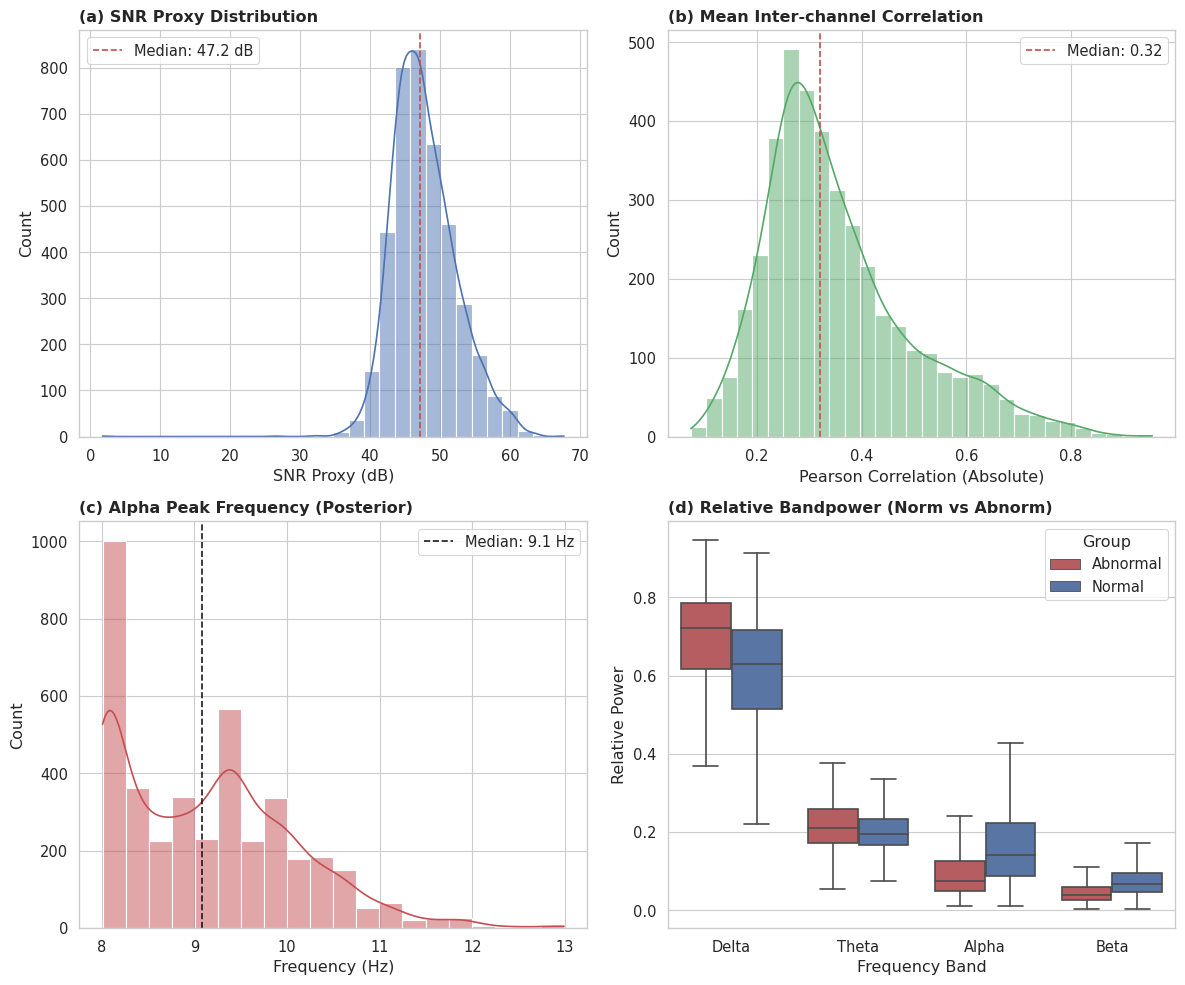

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ==========================================
# CONFIGURATION
# ==========================================
CSV_FILE = "nmt4k_stats_output.csv"
OUTPUT_DIR = Path("figures")
OUTPUT_DIR.mkdir(exist_ok=True)
OUTPUT_FILENAME = OUTPUT_DIR / "fig_signal_qc_grid.png"

# Set style for publication quality
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['font.family'] = 'sans-serif'

def plot_signal_qc(csv_path):
    # 1. Load Data
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Error: Could not find {csv_path}. Run the calculation script first.")
        return

    # Filter out potential NaNs for specific plots
    df_snr = df['snr'].dropna()
    df_corr = df['correlation'].dropna()
    df_alpha = df['alpha_peak'].dropna()
    
    # Prepare Data for Bandpower Plot (Melt for Seaborn)
    bp_cols = ['Delta', 'Theta', 'Alpha', 'Beta']
    df_bp = df.melt(id_vars=['group'], value_vars=bp_cols, 
                    var_name='Band', value_name='Relative Power')
    
    # Exclude 'Unknown' groups if necessary for cleaner plots
    df_bp = df_bp[df_bp['group'].isin(['Normal', 'Abnormal'])]

    # ==========================================
    # CREATE FIGURE (2x2 GRID)
    # ==========================================
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Flatten axes for easy indexing: 0=(a), 1=(b), 2=(c), 3=(d)
    ax = axes.flatten()

    # --- (a) SNR Proxy Distribution ---
    sns.histplot(df_snr, ax=ax[0], kde=True, color="#4C72B0", bins=30)
    ax[0].set_title("(a) SNR Proxy Distribution", fontweight='bold', loc='left')
    ax[0].set_xlabel("SNR Proxy (dB)")
    ax[0].set_ylabel("Count")
    # Add Median Line
    med_snr = df_snr.median()
    ax[0].axvline(med_snr, color='r', linestyle='--', label=f'Median: {med_snr:.1f} dB')
    ax[0].legend()

    # --- (b) Inter-channel Correlation ---
    sns.histplot(df_corr, ax=ax[1], kde=True, color="#55A868", bins=30)
    ax[1].set_title("(b) Mean Inter-channel Correlation", fontweight='bold', loc='left')
    ax[1].set_xlabel("Pearson Correlation (Absolute)")
    ax[1].set_ylabel("Count")
    med_corr = df_corr.median()
    ax[1].axvline(med_corr, color='r', linestyle='--', label=f'Median: {med_corr:.2f}')
    ax[1].legend()

    # --- (c) Alpha Peak Frequency ---
    # Filter for realistic Alpha range to avoid outliers skewing plot
    valid_alpha = df_alpha[(df_alpha >= 7) & (df_alpha <= 14)]
    sns.histplot(valid_alpha, ax=ax[2], kde=True, color="#C44E52", bins=20)
    ax[2].set_title("(c) Alpha Peak Frequency (Posterior)", fontweight='bold', loc='left')
    ax[2].set_xlabel("Frequency (Hz)")
    ax[2].set_ylabel("Count")
    med_alpha = valid_alpha.median()
    ax[2].axvline(med_alpha, color='k', linestyle='--', label=f'Median: {med_alpha:.1f} Hz')
    ax[2].legend()

    # --- (d) Bandpower Comparison (Normal vs Abnormal) ---
    sns.boxplot(data=df_bp, x='Band', y='Relative Power', hue='group', 
                ax=ax[3], palette={'Normal': '#4C72B0', 'Abnormal': '#C44E52'},
                showfliers=False) # Hiding outliers for cleaner view
    ax[3].set_title("(d) Relative Bandpower (Norm vs Abnorm)", fontweight='bold', loc='left')
    ax[3].set_xlabel("Frequency Band")
    ax[3].set_ylabel("Relative Power")
    ax[3].legend(title="Group")

    # ==========================================
    # FINALIZE AND SAVE
    # ==========================================
    plt.tight_layout()
    plt.savefig(OUTPUT_FILENAME, dpi=300, bbox_inches='tight')
    print(f"Success! Plot saved to: {OUTPUT_FILENAME}")
    
    # Optional: Show plot
    # plt.show()

if __name__ == "__main__":
    plot_signal_qc(CSV_FILE)
    